# Notebook 04 — Counterfactual Explanations (DiCE + SHAP-Guided) (V2)
**Thesis**: A Prescriptive and Explainable Hybrid ML Framework for T2D Risk Prediction
**Dataset**: DiaHealth (single dataset)

### Checkpoint Strategy
- Standard CFs: checkpoint `nb04_std_cf_diahealth.pkl`
- SHAP-Guided CFs: checkpoint `nb04_shap_cf_diahealth.pkl`

### Sections
1. Imports
2. Load data, models, XAI results
3. Define modifiable features
4. Standard DiCE counterfactuals
5. SHAP-guided DiCE counterfactuals
6. Alignment score
7. CF quality metrics
8. Comparison tables & plots
9. Clinical case study
10. Save results


In [ ]:
!pip install -q "scipy>=1.14.0,<1.17" "seaborn>=0.13.2" --upgrade
!pip install -q dice-ml shap lime boruta matplotlib



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import dice_ml
from dice_ml import Dice

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print('All imports successful.')


All imports successful.


## 2. Load Data, Models, XAI Results

In [ ]:
# ============================================================
# 2. LOAD DATA, MODELS, XAI RESULTS
# ============================================================
EXP_DIR       = '/kaggle/working/exp_v2'
PROCESSED_DIR = os.path.join(EXP_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(EXP_DIR, 'models')
XAI_DIR       = os.path.join(EXP_DIR, 'results', 'xai')
CF_DIR        = os.path.join(EXP_DIR, 'results', 'counterfactuals')
CKPT_DIR      = os.path.join(EXP_DIR, 'checkpoints')
os.makedirs(CF_DIR, exist_ok=True)

d          = joblib.load(os.path.join(PROCESSED_DIR, 'diahealth_processed.pkl'))
X_train    = d['X_train_res_boruta']
X_test     = d['X_test_boruta']
y_train    = d['y_train_res']
y_test     = d['y_test']
FEATURES   = d['feature_names_boruta']
TARGET_COL = d['target_col']

# Load best (or XGBoost as fallback) model
best_info  = joblib.load(os.path.join(MODELS_DIR, 'best_model_info.pkl'))
best_name  = best_info.get('diahealth', 'XGBoost')
MODEL_FILES = {
    'XGBoost':  'diahealth_xgboost.pkl',
    'LightGBM': 'diahealth_lightgbm.pkl',
    'CatBoost': 'diahealth_catboost.pkl',
}
model_name = best_name if best_name in MODEL_FILES else 'XGBoost'
model      = joblib.load(os.path.join(MODELS_DIR, MODEL_FILES[model_name]))
print(f'Model loaded: {model_name}')

# Load SHAP importance for guided CFs
xai_output      = joblib.load(os.path.join(XAI_DIR, 'xai_results.pkl'))
shap_importance = pd.Series(xai_output['shap_importance'])
shap_values     = xai_output['shap_values']
X_test_shap     = xai_output['X_test_shap']

print(f'Features: {FEATURES}')
print(f'Test shape: {X_test.shape}')
print(f'Top-5 SHAP features: {shap_importance.sort_values(ascending=False).head(5).index.tolist()}')


Model loaded: XGBoost
Features: ['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'weight', 'bmi', 'hypertensive', 'bp_ratio', 'pulse_pressure', 'bmi_age', 'glucose_bmi', 'cardio_risk', 'family_hypertension', 'family_risk']
Test shape: (1088, 16)
Top-5 SHAP features: ['glucose', 'weight', 'bmi_age', 'diastolic_bp', 'glucose_bmi']


## 3. Modifiable Features

In [ ]:
# ============================================================
# 3. MODIFIABLE FEATURES
# ============================================================
# Features that a clinical intervention CAN change.
# Non-modifiable: age, gender, family_diabetes, family_hypertension,
#                 cardiovascular_disease, stroke, family_risk (derived)
MODIFIABLE = [
    f for f in FEATURES
    if f not in [
        'age', 'gender',
        'family_diabetes', 'family_hypertension', 'family_risk',
        'cardiovascular_disease', 'stroke',
    ]
]

print(f'Modifiable features ({len(MODIFIABLE)}): {MODIFIABLE}')
print(f'Non-modifiable (fixed in CFs): {[f for f in FEATURES if f not in MODIFIABLE]}')


Modifiable features (12): ['pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'weight', 'bmi', 'hypertensive', 'bp_ratio', 'pulse_pressure', 'bmi_age', 'glucose_bmi', 'cardio_risk']
Non-modifiable (fixed in CFs): ['age', 'gender', 'family_hypertension', 'family_risk']


## 4. Standard DiCE Counterfactuals (checkpoint)

In [ ]:
# ============================================================
# 4. STANDARD DICE COUNTERFACTUALS (no checkpoint)
# ============================================================

# XGBoost-safe wrapper: casts all columns to float before predict
class _XGBSafeWrapper:
    """Wraps any sklearn-API model; coerces DataFrame dtypes to float."""
    def __init__(self, mdl):
        self._mdl = mdl
        self.classes_ = getattr(mdl, 'classes_', [0, 1])
    def fit(self, X, y): return self
    def _cast(self, X):
        if isinstance(X, pd.DataFrame):
            return X.astype(float)
        return X
    def predict(self, X):
        return self._mdl.predict(self._cast(X))
    def predict_proba(self, X):
        return self._mdl.predict_proba(self._cast(X))

safe_model = _XGBSafeWrapper(model)

print('Generating standard DiCE counterfactuals...')
train_df = X_train.copy(); train_df[TARGET_COL] = y_train.values

data_dice = dice_ml.Data(
    dataframe=train_df,
    continuous_features=[f for f in FEATURES if f in MODIFIABLE],
    outcome_name=TARGET_COL,
)
model_dice = dice_ml.Model(model=safe_model, backend='sklearn')
exp_std    = Dice(data_dice, model_dice, method='genetic')

# Generate CFs for high-risk positives (TP)
y_pred  = model.predict(X_test)
y_prob  = safe_model.predict_proba(X_test)[:, 1]
tp_mask = (y_test == 1) & (y_pred == 1)
tp_idx  = np.where(tp_mask)[0]
n_inst  = min(20, len(tp_idx))
idx_sel = tp_idx[np.argsort(y_prob[tp_mask])[::-1][:n_inst]]

all_cfs = []
for idx in idx_sel:
    try:
        query = X_test.iloc[[idx]][FEATURES]
        cf_res = exp_std.generate_counterfactuals(
            query, total_CFs=3, desired_class='opposite',
            features_to_vary=MODIFIABLE)
        cf_df = cf_res.cf_examples_list[0].final_cfs_df
        cf_df['instance_idx'] = idx
        all_cfs.append(cf_df)
        print(f'  Instance {idx}: {len(cf_df)} CFs generated.')
    except Exception as e:
        print(f'  Instance {idx}: failed ({e})')

standard_cfs = pd.concat(all_cfs, ignore_index=True) if all_cfs else pd.DataFrame()
print(f'Standard CFs ready: {len(standard_cfs)} rows.')


Generating standard DiCE counterfactuals...


100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


  Instance 460: 3 CFs generated.


100%|██████████| 1/1 [00:00<00:00,  2.94it/s]


  Instance 438: 3 CFs generated.


...

  Instance 377: 3 CFs generated.


100%|██████████| 1/1 [00:00<00:00,  2.91it/s]


  Instance 10: 3 CFs generated.


100%|██████████| 1/1 [00:00<00:00,  2.95it/s]

  Instance 32: 3 CFs generated.
Standard CFs ready: 60 rows.


## 5. SHAP-Guided DiCE Counterfactuals (checkpoint)

In [ ]:
# ============================================================
# 5. SHAP-GUIDED DICE COUNTERFACTUALS (no checkpoint)
# ============================================================

print('Generating SHAP-guided DiCE counterfactuals...')
train_df2 = X_train.copy(); train_df2[TARGET_COL] = y_train.values

data_dice2 = dice_ml.Data(
    dataframe=train_df2,
    continuous_features=[f for f in FEATURES if f in MODIFIABLE],
    outcome_name=TARGET_COL,
)
model_dice2 = dice_ml.Model(model=safe_model, backend='sklearn')
exp_shap    = Dice(data_dice2, model_dice2, method='genetic')

# Priority features: SHAP top-K modifiable
shap_mod_rank = shap_importance[
    [f for f in shap_importance.sort_values(ascending=False).index if f in MODIFIABLE]
]
priority_k = max(3, len(MODIFIABLE) // 2)

y_pred  = model.predict(X_test)
y_prob  = safe_model.predict_proba(X_test)[:, 1]
tp_mask = (y_test == 1) & (y_pred == 1)
tp_idx  = np.where(tp_mask)[0]
n_inst  = min(20, len(tp_idx))
idx_sel = tp_idx[np.argsort(y_prob[tp_mask])[::-1][:n_inst]]

all_cfs = []
for idx in idx_sel:
    si   = min(int(idx), len(shap_values) - 1)
    inst_shap = pd.Series(np.abs(shap_values[si]), index=FEATURES)
    pf = [f for f in inst_shap.sort_values(ascending=False).index
          if f in MODIFIABLE][:priority_k]
    try:
        query = X_test.iloc[[idx]][FEATURES]
        cf_res = exp_shap.generate_counterfactuals(
            query, total_CFs=3, desired_class='opposite',
            features_to_vary=pf)
        cf_df = cf_res.cf_examples_list[0].final_cfs_df
        cf_df['instance_idx']           = idx
        cf_df['shap_priority_features'] = str(pf)
        all_cfs.append(cf_df)
        print(f'  Instance {idx}: priorities={pf[:3]}...')
    except Exception as e:
        print(f'  Instance {idx}: failed ({e})')

shap_guided_cfs = pd.concat(all_cfs, ignore_index=True) if all_cfs else pd.DataFrame()
print(f'SHAP-Guided CFs ready: {len(shap_guided_cfs)} rows.')


Generating SHAP-guided DiCE counterfactuals...


100%|██████████| 1/1 [00:00<00:00,  3.02it/s]


  Instance 460: priorities=['glucose', 'cardio_risk', 'bmi']...


100%|██████████| 1/1 [00:00<00:00,  2.99it/s]


  Instance 438: priorities=['glucose', 'weight', 'bmi']...


...

  Instance 377: priorities=['weight', 'glucose', 'bmi_age']...


100%|██████████| 1/1 [00:00<00:00,  2.43it/s]


  Instance 10: priorities=['glucose', 'bmi_age', 'weight']...


100%|██████████| 1/1 [00:00<00:00,  2.98it/s]

  Instance 32: priorities=['cardio_risk', 'glucose_bmi', 'pulse_pressure']...
SHAP-Guided CFs ready: 60 rows.


## 6-8. Alignment, Quality, Comparison

In [ ]:
# ============================================================
# 6. ALIGNMENT SCORE
# ============================================================
def compute_alignment(original, cf, shap_vals, features, modifiable):
    num = den = 0.0
    for j, f in enumerate(features):
        if f not in modifiable:
            continue
        s = abs(shap_vals[j]); den += s
        if f in cf.index and f in original.index:
            if abs(float(cf[f]) - float(original[f])) > 1e-6:
                num += s
    return num / den if den > 0 else 0.0

alignment_results = {}
for method, cfs_df in [('standard', standard_cfs), ('shap_guided', shap_guided_cfs)]:
    if len(cfs_df) == 0:
        alignment_results[method] = []
        continue
    scores = []
    for idx in cfs_df['instance_idx'].unique():
        orig = X_test.iloc[int(idx)]
        si   = min(int(idx), len(shap_values) - 1)
        for _, cr in cfs_df[cfs_df['instance_idx'] == idx].iterrows():
            scores.append(compute_alignment(orig, cr, shap_values[si], FEATURES, MODIFIABLE))
    alignment_results[method] = scores
    if scores:
        print(f'{method:15s}: mean={np.mean(scores):.4f}  median={np.median(scores):.4f}')

print('Alignment computed.')


standard       : mean=0.7524  median=0.7999
shap_guided    : mean=0.6605  median=0.6808
Alignment computed.


In [ ]:
# ============================================================
# 7. CF QUALITY METRICS
# ============================================================
def cf_quality(original, cf, features, modifiable, mdl):
    l1 = n_chg = 0
    for f in modifiable:
        if f in features and f in cf.index and f in original.index:
            delta = abs(float(cf[f]) - float(original[f]))
            l1 += delta
            if delta > 1e-6:
                n_chg += 1
    n_mod = len([f for f in modifiable if f in features])
    sp    = n_chg / max(n_mod, 1)
    try:
        _cf_arr   = pd.DataFrame(cf[features].values.reshape(1, -1), columns=features).astype(float)
        _orig_arr = pd.DataFrame(original[features].values.reshape(1, -1), columns=features).astype(float)
        cf_pred   = mdl.predict(_cf_arr)[0]
        orig_pred = mdl.predict(_orig_arr)[0]
        valid = int(cf_pred != orig_pred)
    except Exception as _e:
        valid = -1
        print(f'      cf_quality predict failed: {_e}')
    return {'proximity_l1': l1, 'sparsity': sp, 'n_changed': n_chg, 'valid': valid}

quality_results = {}
for method, cfs_df in [('standard', standard_cfs), ('shap_guided', shap_guided_cfs)]:
    if len(cfs_df) == 0:
        quality_results[method] = []
        continue
    mq = []
    for idx in cfs_df['instance_idx'].unique():
        orig = X_test.iloc[int(idx)]
        for _, cr in cfs_df[cfs_df['instance_idx'] == idx].iterrows():
            mq.append(cf_quality(orig, cr, FEATURES, MODIFIABLE, model))
    quality_results[method] = mq
    qd = pd.DataFrame(mq)
    print(f'{method:15s}: prox={qd["proximity_l1"].mean():.3f}  '
          f'sparse={qd["sparsity"].mean():.3f}  valid={qd["valid"].mean():.1%}')

print('Quality metrics computed.')


standard       : prox=179.724  sparse=0.804  valid=98.3%
shap_guided    : prox=107.895  sparse=0.490  valid=98.3%
Quality metrics computed.



CF Comparison Table:


,method,alignment_mean,proximity_mean,sparsity_mean,validity,n_cfs
0,standard,0.752353,179.724294,0.804167,0.983333,60
1,shap_guided,0.660478,107.894630,0.490278,0.983333,60


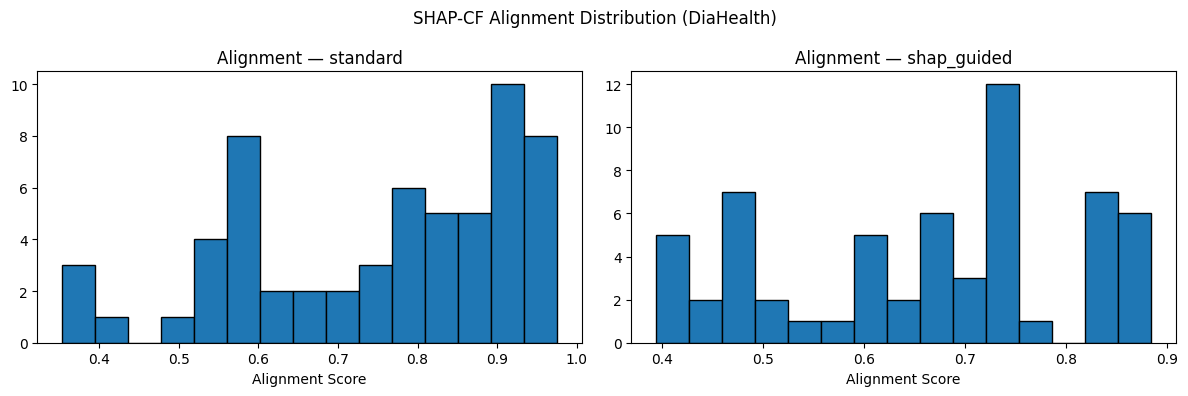

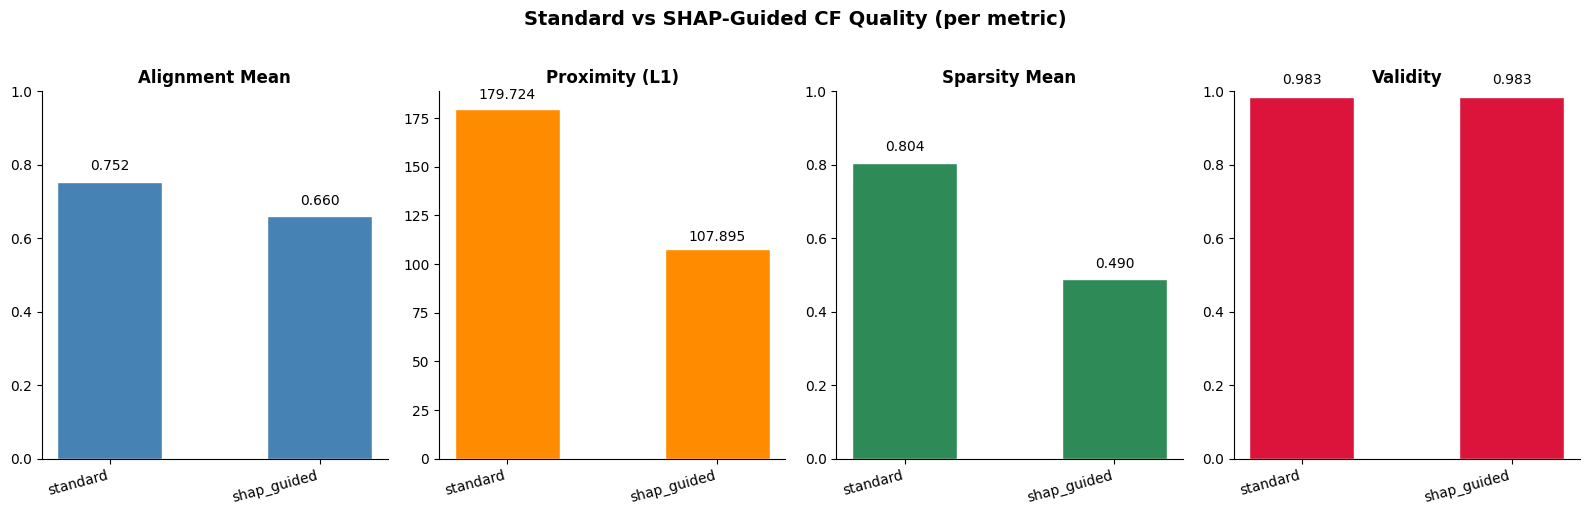

In [ ]:
# ============================================================
# 8. COMPARISON TABLE + PLOTS
# ============================================================
comp_rows = []
for method in ['standard', 'shap_guided']:
    al = alignment_results.get(method, [])
    qd = pd.DataFrame(quality_results.get(method, []))
    if len(qd) == 0:
        continue
    comp_rows.append({
        'method':           method,
        'alignment_mean':   np.mean(al) if al else 0,
        'proximity_mean':   qd['proximity_l1'].mean(),
        'sparsity_mean':    qd['sparsity'].mean(),
        'validity':         qd['valid'].mean(),
        'n_cfs':            len(qd),
    })

comp_df = pd.DataFrame(comp_rows)
print('\nCF Comparison Table:')
display(comp_df)

# Alignment distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, method in zip(axes, ['standard', 'shap_guided']):
    sc = alignment_results.get(method, [])
    if sc:
        ax.hist(sc, bins=15, edgecolor='black')
    ax.set_title(f'Alignment — {method}')
    ax.set_xlabel('Alignment Score')
plt.suptitle('SHAP-CF Alignment Distribution (DiaHealth)')
plt.tight_layout()
plt.savefig(os.path.join(CF_DIR, 'alignment_distribution.png'), dpi=150)
plt.show()

# Separate subplots per metric (proximity scale differs from 0-1 metrics)
if len(comp_df) > 0:
    _metrics = [
        ('alignment_mean',  'Alignment Mean',   'steelblue',  (0, 1)),
        ('proximity_mean',  'Proximity (L1)',   'darkorange',  None),
        ('sparsity_mean',   'Sparsity Mean',    'seagreen',   (0, 1)),
        ('validity',        'Validity',         'crimson',    (0, 1)),
    ]
    _methods = comp_df['method'].tolist()
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (col, label, color, ylim) in zip(axes, _metrics):
        if col not in comp_df.columns:
            ax.set_visible(False)
            continue
        vals = comp_df.set_index('method')[col]
        bars = ax.bar(_methods, vals, color=color, edgecolor='white', width=0.5)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(_methods)))
        ax.set_xticklabels(_methods, rotation=15, ha='right')
        if ylim:
            ax.set_ylim(*ylim)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (bar.get_height() * 0.02 + 0.01),
                    f'{v:.3f}', ha='center', va='bottom', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    fig.suptitle('Standard vs SHAP-Guided CF Quality (per metric)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(CF_DIR, 'comparison_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 9. Clinical Case Study

In [ ]:
# ============================================================
# 9. CLINICAL CASE STUDY
# ============================================================
print('\n' + '='*70)
print('CLINICAL CASE STUDY — DiaHealth')
print('='*70)

y_prob  = safe_model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)
tp_mask = (y_test == 1) & (y_pred == 1)
tp_idx  = np.where(tp_mask)[0]

if len(tp_idx) == 0:
    print('No true positives found — using highest-risk instance.')
    tp_idx = [np.argmax(y_prob)]

bi   = tp_idx[np.argmax(y_prob[tp_mask]) if tp_mask.sum() > 0 else 0]
orig = X_test.iloc[bi]

print(f'\nPatient index : {bi}')
print(f'Predicted risk: {y_prob[bi]:.4f}')
print(f'True label    : {y_test.iloc[bi]}')
print('\nPatient profile:')
for f in FEATURES:
    print(f'  {f:28s}: {orig[f]:.4f}')

if len(shap_guided_cfs) > 0 and bi in shap_guided_cfs['instance_idx'].values:
    ic = shap_guided_cfs[shap_guided_cfs['instance_idx'] == bi]
    if len(ic) > 0:
        cf = ic.iloc[0]
        print('\n  Clinical Recommendations (SHAP-Guided CF):')
        for f in FEATURES:
            if f in cf.index:
                ch = float(cf[f]) - float(orig[f])
                if abs(ch) > 1e-6:
                    arrow = 'UP' if ch > 0 else 'DOWN'
                    print(f'    {f:28s}: {float(orig[f]):.2f} -> {float(cf[f]):.2f} '
                          f'({arrow} {abs(ch):.2f})')
else:
    print('\n  (No SHAP-guided CF available for this instance.)')

print('\nCase study done.')



CLINICAL CASE STUDY — DiaHealth

Patient index : 460
Predicted risk: 0.9924
True label    : 1

Patient profile:
  age                         : 60.0000
  gender                      : 0.0000
  pulse_rate                  : 84.0000
  systolic_bp                 : 145.0000
  diastolic_bp                : 87.0000
  glucose                     : 11.3000
  weight                      : 54.0000
  bmi                         : 22.4900
  hypertensive                : 1.0000
  bp_ratio                    : 1.6477
  pulse_pressure              : 58.0000
  bmi_age                     : 1349.4000
  glucose_bmi                 : 254.1370
  cardio_risk                 : 1.0000
  family_hypertension         : 0.0000
  family_risk                 : 0.0000

  Clinical Recommendations (SHAP-Guided CF):
    diastolic_bp                : 87.00 -> 77.00 (DOWN 10.00)
    glucose                     : 11.30 -> 8.30 (DOWN 3.00)
    bmi                         : 22.49 -> 21.41 (DOWN 1.08)
    bp_ratio        

## 10. Save CF Results

In [ ]:
# ============================================================
# 10. SAVE ALL CF RESULTS
# ============================================================
cf_output = {
    'standard_cfs':     standard_cfs.to_dict() if len(standard_cfs) > 0 else {},
    'shap_guided_cfs':  shap_guided_cfs.to_dict() if len(shap_guided_cfs) > 0 else {},
    'alignment_results': alignment_results,
    'quality_results':   quality_results,
    'comparison':        comp_df.to_dict() if len(comp_df) > 0 else {},
    'model_name':        model_name,
}
joblib.dump(cf_output, os.path.join(CF_DIR, 'cf_results.pkl'))
comp_df.to_csv(os.path.join(CF_DIR, 'cf_comparison.csv'), index=False)
if len(standard_cfs) > 0:
    standard_cfs.to_csv(os.path.join(CF_DIR, 'diahealth_standard_cfs.csv'), index=False)
if len(shap_guided_cfs) > 0:
    shap_guided_cfs.to_csv(os.path.join(CF_DIR, 'diahealth_shap_guided_cfs.csv'), index=False)

print(f'Saved to {CF_DIR}')
for f in sorted(os.listdir(CF_DIR)):
    print(f'  {f}')
print()
print('Notebook 04 complete! Proceed to 05_summary.ipynb')


Saved to /kaggle/working/exp_v2/results/counterfactuals
  alignment_distribution.png
  cf_comparison.csv
  cf_results.pkl
  comparison_metrics.png
  diahealth_shap_guided_cfs.csv
  diahealth_standard_cfs.csv

Notebook 04 complete! Proceed to 05_summary.ipynb
